In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from imblearn.over_sampling import SMOTE

import joblib
import warnings
warnings.filterwarnings("ignore")


In [3]:
df=pd.read_csv("/content/dataset.csv")

In [4]:
print(df.head())

  policy_id  policy_tenure  age_of_car  age_of_policyholder area_cluster  \
0   ID00001       0.515874        0.05             0.644231           C1   
1   ID00002       0.672619        0.02             0.375000           C2   
2   ID00003       0.841110        0.02             0.384615           C3   
3   ID00004       0.900277        0.11             0.432692           C4   
4   ID00005       0.596403        0.11             0.634615           C5   

  population_density  make  is_claim segment model  ...  \
0               4990     1         0       A    M1  ...   
1             27003"     1         0       A    M1  ...   
2               4076     1         0       A    M1  ...   
3             21622"     1         0      C1    M2  ...   
4              34738     2         0       A    M3  ...   

  is_rear_window_defogger is_brake_assist is_power_door_locks  \
0                      No              No                  No   
1                      No              No                 

In [5]:
df.shape

(26815, 44)

In [6]:
print(df.tail())

      policy_id  policy_tenure  age_of_car  age_of_policyholder area_cluster  \
26810   ID26811       0.296023        0.03             0.500000          C14   
26811   ID26812       0.379037        0.08             0.326923           C8   
26812   ID26813       1.087008        0.09             0.413462           C5   
26813   ID26814       0.281078        0.14             0.480769          C10   
26814   ID26815       1.159854        0.09             0.673077           C3   

      population_density  make  is_claim segment model  ...  \
26810               7788     4         0      B2    M5  ...   
26811               8794     1         0      B2    M6  ...   
26812              34738     3         0      C2    M4  ...   
26813              73430     1         0      B2    M6  ...   
26814               4076     3         0      C2    M4  ...   

      is_rear_window_defogger is_brake_assist is_power_door_locks  \
26810                      No              No                 Yes   
26

In [7]:
df.dropna(inplace=True)
print(df.isna().sum())

policy_id                           0
policy_tenure                       0
age_of_car                          0
age_of_policyholder                 0
area_cluster                        0
population_density                  0
make                                0
is_claim                            0
segment                             0
model                               0
fuel_type                           0
max_torque                          0
max_power                           0
engine_type                         0
airbags                             0
is_esc                              0
is_adjustable_steering              0
is_tpms                             0
is_parking_sensors                  0
is_parking_camera                   0
rear_brakes_type                    0
displacement                        0
cylinder                            0
transmission_type                   0
gear_box                            0
steering_type                       0
turning_radi

In [8]:
df.drop("policy_id",inplace=True,axis=1)

In [9]:
df.describe()

,policy_tenure,age_of_car,age_of_policyholder,make,is_claim,airbags,displacement,cylinder,gear_box,turning_radius,height,ncap_rating
count,26814.000000,26814.000000,26814.000000,26814.000000,26814.000000,26814.000000,26814.000000,26814.000000,26814.000000,26814.000000,26814.000000,26814.000000
mean,0.612753,0.069217,0.468984,1.759864,0.064630,3.130492,1161.195308,3.625942,5.242821,4.851702,1552.905124,1.753301
std,0.414492,0.056530,0.122689,1.136340,0.245877,1.829841,266.272754,0.483888,0.428796,0.227663,79.627395,1.393827
min,0.002739,0.000000,0.288462,1.000000,0.000000,1.000000,796.000000,3.000000,5.000000,4.500000,1475.000000,0.000000
25%,0.206977,0.020000,0.365385,1.000000,0.000000,2.000000,796.000000,3.000000,5.000000,4.600000,1475.000000,0.000000
50%,0.576353,0.060000,0.451923,1.000000,0.000000,2.000000,1197.000000,4.000000,5.000000,4.800000,1530.000000,2.000000
75%,1.040049,0.110000,0.548077,3.000000,0.000000,6.000000,1493.000000,4.000000,5.000000,5.000000,1635.000000,3.000000
max,1.376478,1.000000,0.971154,5.000000,1.000000,6.000000,1498.000000,4.000000,6.000000,5.200000,1825.000000,5.000000


In [10]:
df.columns

Index(['policy_tenure', 'age_of_car', 'age_of_policyholder', 'area_cluster',
       'population_density', 'make', 'is_claim', 'segment', 'model',
       'fuel_type', 'max_torque', 'max_power', 'engine_type', 'airbags',
       'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder',
       'transmission_type', 'gear_box', 'steering_type', 'turning_radius',
       'Length', 'width', 'height', 'Gross_weight', 'is_front_fog_lights',
       'is_rear_window_wiper', 'is_rear_window_washer',
       'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks',
       'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
       'is_ecw', 'is_speed_alert', 'ncap_rating'],
      dtype='object')

In [11]:
df.fillna(df.mean(numeric_only=True),inplace=True)
df.fillna(df.mode().iloc[0],inplace=True)


In [12]:
df["rpm_T"]=df["max_torque"].str.extract(r'@(\d+)').astype(float)
df["torque"]=df["max_torque"].str.extract(r'(\d+)').astype(float)

df["rpm_P"]=df["max_power"].str.extract(r'@(\d+)').astype(float)
df["power"]=df["max_power"].str.extract(r'(\d+)').astype(float)

In [13]:
df["torque_rpm_ratio"]=df["torque"]/df["rpm_T"]
df["power_rpm_ratio"]=df["power"]/df["rpm_P"]

In [14]:
df['population_density']=(df["population_density"].astype(str).str.replace(r"[^0-9.]","",regex=True).astype(float))

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26814 entries, 0 to 26813
Data columns (total 49 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_tenure                     26814 non-null  float64
 1   age_of_car                        26814 non-null  float64
 2   age_of_policyholder               26814 non-null  float64
 3   area_cluster                      26814 non-null  object 
 4   population_density                26814 non-null  float64
 5   make                              26814 non-null  int64  
 6   is_claim                          26814 non-null  int64  
 7   segment                           26814 non-null  object 
 8   model                             26814 non-null  object 
 9   fuel_type                         26814 non-null  object 
 10  max_torque                        26814 non-null  object 
 11  max_power                         26814 non-null  object 
 12  engine_ty

In [16]:
le=LabelEncoder()

categorical_cols=df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col]=le.fit_transform(df[col])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26814 entries, 0 to 26813
Data columns (total 49 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_tenure                     26814 non-null  float64
 1   age_of_car                        26814 non-null  float64
 2   age_of_policyholder               26814 non-null  float64
 3   area_cluster                      26814 non-null  int64  
 4   population_density                26814 non-null  float64
 5   make                              26814 non-null  int64  
 6   is_claim                          26814 non-null  int64  
 7   segment                           26814 non-null  int64  
 8   model                             26814 non-null  int64  
 9   fuel_type                         26814 non-null  int64  
 10  max_torque                        26814 non-null  int64  
 11  max_power                         26814 non-null  int64  
 12  engine_ty

In [18]:
categorical_cols=[ "segment","area_cluster","model","fuel_type","engine_type","rear_brakes_type","transmission_type","steering_type"]

df=pd.get_dummies(df,columns=categorical_cols,drop_first=True)

In [19]:
df.shape

(26814, 93)

In [20]:
x=df.drop("is_claim",axis=1)
y=df["is_claim"]

print("Total Features:",x.shape[1])

Total Features: 92


In [21]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42)

In [22]:
scaler=StandardScaler()

x_train=pd.DataFrame(scaler.fit_transform(x_train),columns=x_train.columns)
x_test=pd.DataFrame(scaler.transform(x_test),columns=x_test.columns)

In [23]:
smote=SMOTE(random_state=42)
x_train_res,y_train_res=smote.fit_resample(x_train,y_train)

In [24]:
models={
    "LogisticRegression":LogisticRegressionCV(),
    "KNeighborsClassifier":KNeighborsClassifier(n_neighbors=100),
    "SVM":SVC(),
    "DecisionTreeClassifier":DecisionTreeClassifier(random_state=42)
}


In [25]:
result=[]

for name,model in models.items():
    model.fit(x_train_res,y_train_res)
    y_pred=model.predict(x_test)

    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)

    result.append([name,accuracy,precision,recall,f1])

    print(f"\n{name}")
    print('Accuracy:',accuracy)
    print('Precision:',precision)
    print('Recall:',recall)
    print('F1 Score:',f1)


LogisticRegression
Accuracy: 0.5892224501212008
Precision: 0.08366711170449488
Recall: 0.5662650602409639
F1 Score: 0.14579294300116324

KNeighborsClassifier
Accuracy: 0.5166884206600784
Precision: 0.0709946848899013
Recall: 0.5632530120481928
F1 Score: 0.1260957518543493

SVM
Accuracy: 0.5194853626701473
Precision: 0.07879924953095685
Recall: 0.6325301204819277
F1 Score: 0.14014014014014015

DecisionTreeClassifier
Accuracy: 0.8474734290509044
Precision: 0.07517482517482517
Recall: 0.12951807228915663
F1 Score: 0.09513274336283185


In [26]:
best_model=models["DecisionTreeClassifier"]


<Axes: >

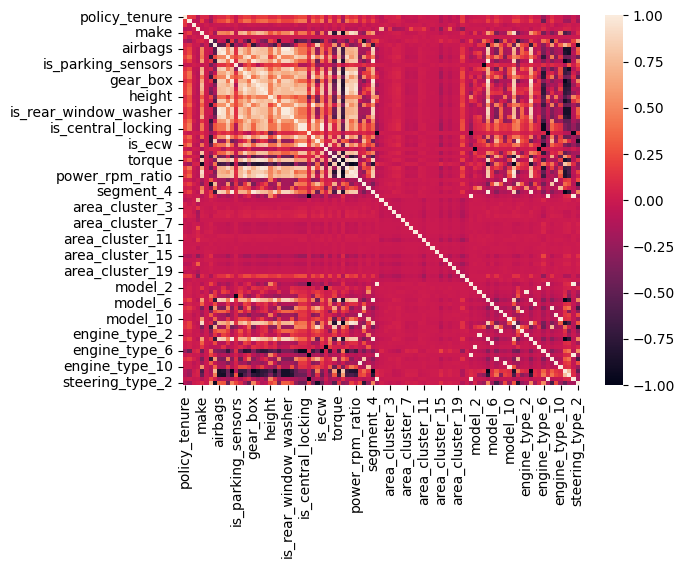

In [27]:
sns.heatmap(df.corr())

In [29]:
joblib.dump(
    {
        "model": best_model,
        "scaler": scaler,
        "feature_columns": x.columns.tolist()
    },
    "insurance_bundle.pkl"
)

print("Model saved successfully!")


Model saved successfully!


In [30]:
print("Machine Learning Model Trained on These Features :",x.columns.tolist())

Machine Learning Model Trained on These Features : ['policy_tenure', 'age_of_car', 'age_of_policyholder', 'population_density', 'make', 'max_torque', 'max_power', 'airbags', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'displacement', 'cylinder', 'gear_box', 'turning_radius', 'Length', 'width', 'height', 'Gross_weight', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert', 'ncap_rating', 'rpm_T', 'torque', 'rpm_P', 'power', 'torque_rpm_ratio', 'power_rpm_ratio', 'segment_1', 'segment_2', 'segment_3', 'segment_4', 'segment_5', 'area_cluster_1', 'area_cluster_2', 'area_cluster_3', 'area_cluster_4', 'area_cluster_5', 'area_cluster_6', 'area_cluster_7', 'area_cluster_8', 'area_cluster_9', 'area_cluster_10', 'area_cluster_1